In [2]:
####################################
#ENVIRONMENT SETUP

In [3]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime

In [4]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [5]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "CaseStudies")
dataType = "ConvectiveCores"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/CaseStudies



In [6]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [7]:
#Setup

Region = "TRACER"; Case = "WET"; spinup_hours = "0"
# Region = "TRACER"; Case = "DIURNAL"; spinup_hours = "-5"
# Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
# Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

# Region = "Hawaii"; Case = "WET"; spinup_hours = "12"
# Region = "Hawaii"; Case = "TRADES"; spinup_hours = "24" 

In [8]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = (Region,Case,"TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-07-01 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:193
 # Diag Files:   193
 # Time Steps:   193
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs
 Static File:    TRACER_regional5250_scaled3_

In [9]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSaving import DataSaving_Class

In [10]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import RadarPlotting_Class

In [11]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [12]:
#IMPORT FUNCTIONS
# --- Add your Functions folder to sys.path ---
import sys
path = os.path.join(DirectoryManager.mainCodeDirectory, 'Functions_2.0')
sys.path.append(path)


# --- Import all your function modules ---
import importlib
modules = [
    "AreaAverageFunctions",
    "ComputationFunctions",
    "DataFunctions",
    "DerivativeFunctions",
    "PlottingFunctions",
    "StatisticalFunctions",
]
for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [13]:
###############
#JOB ARRAY SETUP

In [14]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_JobArray import JobArray_Class

In [15]:
####################################
#CALCULATION FUNCTIONS

In [16]:
def GetMean(variableSubset, mode="xy"):
    #(1/A) ∫ φ dA
    # dA = R² cos(lat) dlat dlon → weight = cos(lat)

    weights = np.cos(np.deg2rad(variableSubset.latitude))

    if mode == "xy":
        dims = ("latitude", "longitude")
    elif mode == "y":
        dims = ("latitude",)
    elif mode == "x":
        dims = ("longitude",)
    else:
        raise ValueError("mode must be 'xy' or 'y'")

    variableMean = variableSubset.weighted(weights).mean(
        dim=dims,
        skipna=True
    )

    return variableMean

def MeanDBZ(variableSubset, mode="xy"):
    # Convert dBZ → linear Z
    variableSubset_power = 10 ** (variableSubset / 10.0)

    # Take weighted mean
    variableMean = GetMean(variableSubset_power, mode=mode)

    # Convert back to dBZ
    variableMean = 10.0 * np.log10(variableMean)

    return variableMean

In [17]:
####################################
#LOADING FUNCTIONS

In [18]:
def GetData(ModelData, varName, t, zTarget=None):
        
    #Loading Data
    [dataSubset,dataSubset_diag,dataSubset_static, lat,lon,zGrid_f,zGrid_c, _, _] = DataOperator_Class.GetData_Subset(ModelData, t)
        
    #Subsetting Data
    variableSubset= GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName)
    
    #Interpolating Z levels #*INTERPOLATION
    #################################
    if any(dim.startswith("nVertLevels") for dim in variableSubset.dims):
        if zTarget is None:
            [zTarget_f, zTarget_c] = ModelData.GetZTarget(zGrid_f, zGrid_c)
            zTarget = "loaded"
        variableSubset = ModelData.InterpolateVertical(variableSubset,zGrid_f,zGrid_c,zTarget_f,zTarget_c)
    #################################            
    
    if varName in ['refl10cm','refl10cm_1km']:
        variableSubset = variableSubset.where(variableSubset > 0)

    return variableSubset
    
def GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName):
    """
    Retrieves a variable subset from the given model data.
    If varName contains a '+', returns the sum of the two variables.
    """
    if '+' in varName:
        var1, var2 = varName.split('+')
        var1 = var1.strip()
        var2 = var2.strip()

        subset1 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var1)
        subset2 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var2)
        variableSubset = subset1 + subset2
    else:
        variableSubset = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                             dataSubset_diag, dataSubset_static, varName)

    return variableSubset

In [19]:
timeStringDictionary = {
    "TRACER": {
        "WET": {
            0: f"2022-07-01_18.00.00",
        },
        "DIURNAL": {
            -5: f"2022-06-22_21.00.00",
        },
    },
    "PRECIP": {
        "WET": {
            12: f"2022-06-07_03.00.00",
        },
        "DIURNAL": {
            12: f"2022-07-16_05.00.00",
        },
    },
    "Hawaii": {
        "WET": {
            12: f"2021-12-06_23.00.00",
        },
        "TRADES": {
            24: f"2022-08-08_01.00.00",
        },
    },
}

In [20]:
selectedTimeString = timeStringDictionary[ModelData_NSSL.region][ModelData_NSSL.case][int(ModelData_NSSL.spinup_hours)]
t = ModelData_NSSL.timeStrings.index(selectedTimeString)
varData_NSSL = GetData(ModelData_NSSL, 'refl10cm',t)
varData_TEMPO = GetData(ModelData_TEMPO, 'refl10cm',t)

In [21]:
############################################################################
""" STRAIGHT RECTANGLE """

' STRAIGHT RECTANGLE '

In [22]:
####################################
#PLOTTING FUNCTIONS

In [23]:
def PlotRectangle(lon_min, lon_max,
                  lat_min, lat_max):
    
    rect = Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    
    ax.add_patch(rect)
from matplotlib.patches import Rectangle

In [24]:
def PlotRectangleFromCenterLine(ax,
                                lon0, lat0,
                                lon1, lat1,
                                width,
                                edgecolor='red',
                                linewidth=2):

    # direction vector
    dx = lon1 - lon0
    dy = lat1 - lat0
    L = np.sqrt(dx**2 + dy**2)

    ux = dx / L
    uy = dy / L

    # perpendicular vector
    px = -uy
    py = ux

    # half width
    w = width / 2

    # rectangle corners
    p1 = (lon0 + px*w, lat0 + py*w)
    p2 = (lon1 + px*w, lat1 + py*w)
    p3 = (lon1 - px*w, lat1 - py*w)
    p4 = (lon0 - px*w, lat0 - py*w)

    rect = Polygon([p1, p2, p3, p4],
                   closed=True,
                   edgecolor=edgecolor,
                   facecolor='none',
                   linewidth=linewidth)

    ax.add_patch(rect)
from matplotlib.patches import Polygon

In [25]:
def GetVerticalDim(data):
    if "nVertLevels" in data.dims:
        return "nVertLevels"
    elif "nVertLevelsP1" in data.dims:
        return "nVertLevelsP1"
    else:
        raise ValueError("No vertical dimension found")

In [26]:
def PlotHorizontalVertical(subsetData,varMean,varName,
                           cmap='turbo',levels=None):
    
    fig = plt.figure(figsize=(12,4))
    
    # Outer grid: plots + colorbar
    outer = gridspec.GridSpec(1, 2, width_ratios=[20,1], wspace=0.05)
    
    # Inner grid: only the two plots
    inner = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[0], wspace=0.25
    )
    
    ax0 = fig.add_subplot(inner[0])
    ax1 = fig.add_subplot(inner[1])
    cax = fig.add_subplot(outer[1])

    zdim = GetVerticalDim(subsetData)

    p1 = subsetData.sel({zdim:3000}, method='nearest').plot(
        ax=ax0,
        cmap=cmap,
        levels=levels,
        add_colorbar=False
    )
    
    p2 = varMean.plot(
        ax=ax1,
        cmap=cmap,
        levels=levels,
        add_colorbar=False
    )
    
    ax0.set_title("Horizontal Zoom-In")
    ax1.set_title("Average")
    
    fig.colorbar(p1, cax=cax, label=varName)

In [27]:
####################################
#PLOTTING

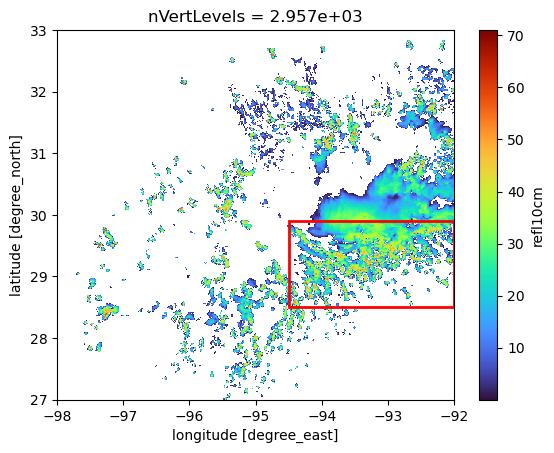

In [28]:
#Plotting with Rectangle

#Make Plot
fig, ax = plt.subplots()
varData_TEMPO.sel(nVertLevels=3000, method='nearest').plot(
    ax=ax, cmap='turbo'
)

#Draw Rectangle
lon_min, lon_max = -94.5, -92
lat_min, lat_max = 28.5, 29.9
PlotRectangle(lon_min, lon_max,
              lat_min, lat_max)

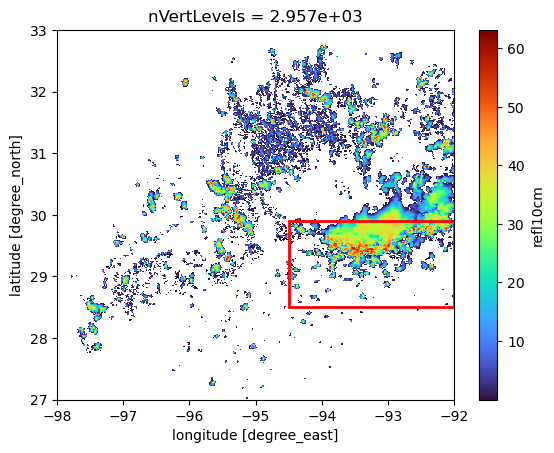

In [29]:
#Plotting with Rectangle

#Make Plot
fig, ax = plt.subplots()
varData_NSSL.sel(nVertLevels=3000, method='nearest').plot(
    ax=ax, cmap='turbo'
)

#Draw Rectangle
lon_min, lon_max = -94.5, -92
lat_min, lat_max = 28.5, 29.9
PlotRectangle(lon_min, lon_max,
              lat_min, lat_max)

In [30]:
####################################
#CALCULATING

In [31]:
#subsetting
subsetData_NSSL = varData_NSSL.sel(
    nVertLevels=slice(0,16000),
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max)
)

subsetData_TEMPO = varData_TEMPO.sel(
    nVertLevels=slice(0,16000),
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_min, lat_max)
)

#mean
varMean_NSSL = GetMean(subsetData_NSSL,mode="y")
varMean_TEMPO = GetMean(subsetData_TEMPO,mode="y")

In [32]:
####################################
#PLOTTING

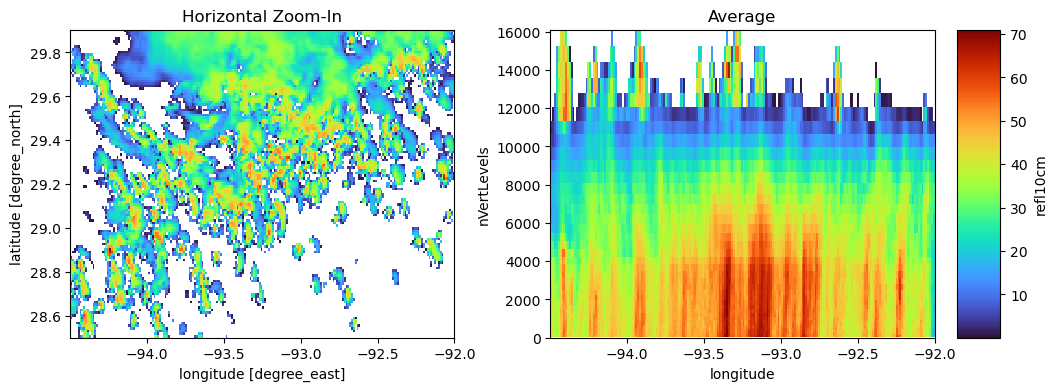

In [33]:
PlotHorizontalVertical(subsetData_TEMPO,varMean_TEMPO,varName="refl10cm")

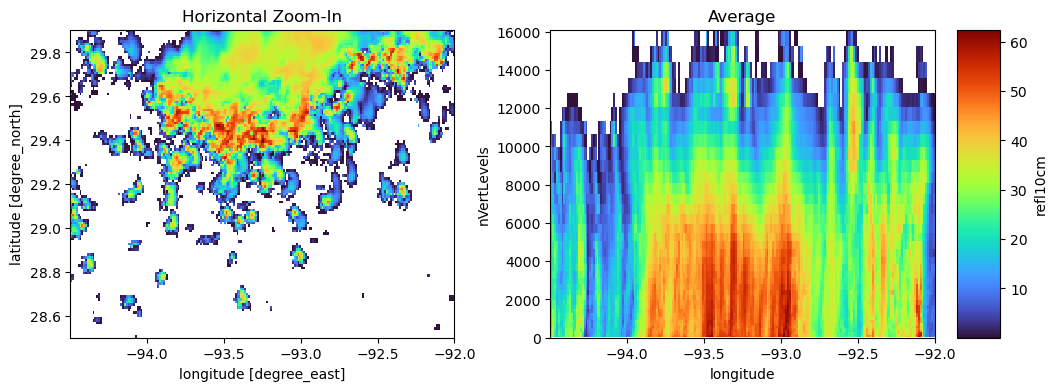

In [34]:
PlotHorizontalVertical(subsetData_NSSL,varMean_NSSL,varName="refl10cm")

In [96]:
# Other Variables
varName = 'w'
varData_NSSL = GetData(ModelData_NSSL, varName,t)
varData_TEMPO = GetData(ModelData_TEMPO, varName,t)

#reflectivity threshold
reflData_NSSL = GetData(ModelData_NSSL, "refl10cm",t).interp(nVertLevels=varData_NSSL.nVertLevelsP1)
reflData_TEMPO = GetData(ModelData_TEMPO, "refl10cm",t).interp(nVertLevels=varData_NSSL.nVertLevelsP1)
varData_NSSL = varData_NSSL.where(reflData_NSSL>40)
varData_TEMPO = varData_TEMPO.where(reflData_TEMPO>40)

# varData_NSSL=varData_NSSL-varData_NSSL.mean() #for perturbations
# varData_TEMPO=varData_TEMPO-varData_TEMPO.mean() #for perturbations

zdim = GetVerticalDim(varData_NSSL)
subsetData_NSSL = varData_NSSL.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

subsetData_TEMPO = varData_TEMPO.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

#mean
varMean_NSSL = GetMean(subsetData_NSSL,mode="y")
varMean_TEMPO = GetMean(subsetData_TEMPO,mode="y")

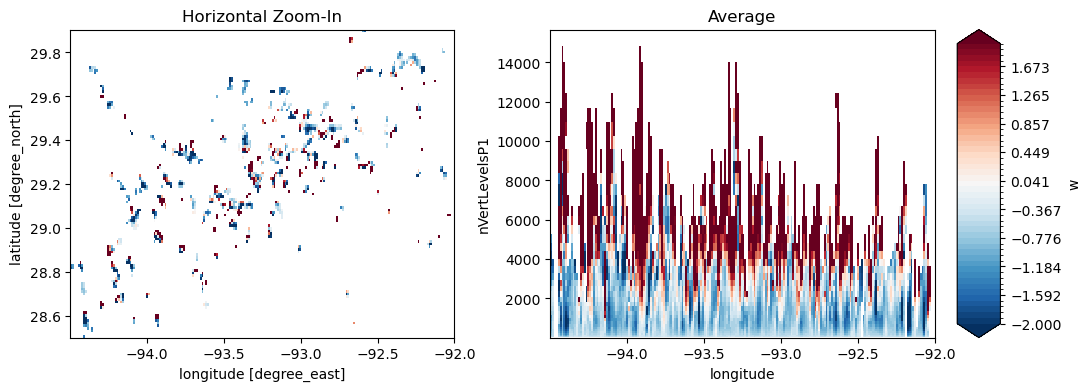

In [98]:
PlotHorizontalVertical(subsetData_TEMPO,varMean_TEMPO,varName="w",
                       cmap='RdBu_r',levels=np.linspace(-2,2))

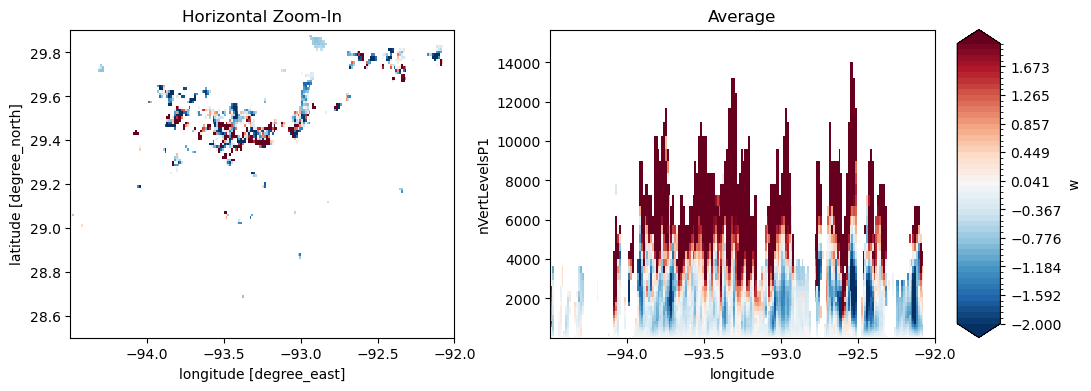

In [95]:
PlotHorizontalVertical(subsetData_NSSL,varMean_NSSL,varName="w",
                       cmap='RdBu_r',levels=np.linspace(-2,2))

In [92]:
# Other Variables
varName = 'qc+qi'
varData_NSSL = GetData(ModelData_NSSL, varName,t)
varData_TEMPO = GetData(ModelData_TEMPO, varName,t)

#reflectivity threshold
reflData_NSSL = GetData(ModelData_NSSL, "refl10cm",t)#.interp(nVertLevels=varData_NSSL.nVertLevelsP1)
reflData_TEMPO = GetData(ModelData_TEMPO, "refl10cm",t)#.interp(nVertLevels=varData_NSSL.nVertLevelsP1)
varData_NSSL = varData_NSSL.where(reflData_NSSL>40)
varData_TEMPO = varData_TEMPO.where(reflData_TEMPO>40)

# varData_NSSL=varData_NSSL-varData_NSSL.mean() #for perturbations
# varData_TEMPO=varData_TEMPO-varData_TEMPO.mean() #for perturbations

zdim = GetVerticalDim(varData_NSSL)
subsetData_NSSL = varData_NSSL.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

subsetData_TEMPO = varData_TEMPO.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

#mean
varMean_NSSL = GetMean(subsetData_NSSL,mode="y")
varMean_TEMPO = GetMean(subsetData_TEMPO,mode="y")

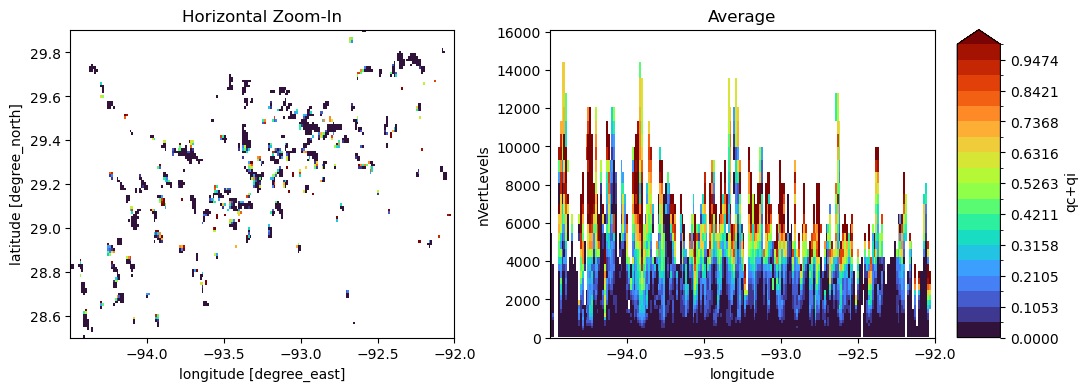

In [430]:
PlotHorizontalVertical(subsetData_TEMPO*1000,varMean_TEMPO*1000,varName="qc+qi",
                       cmap='turbo',levels=np.linspace(0,1,20))

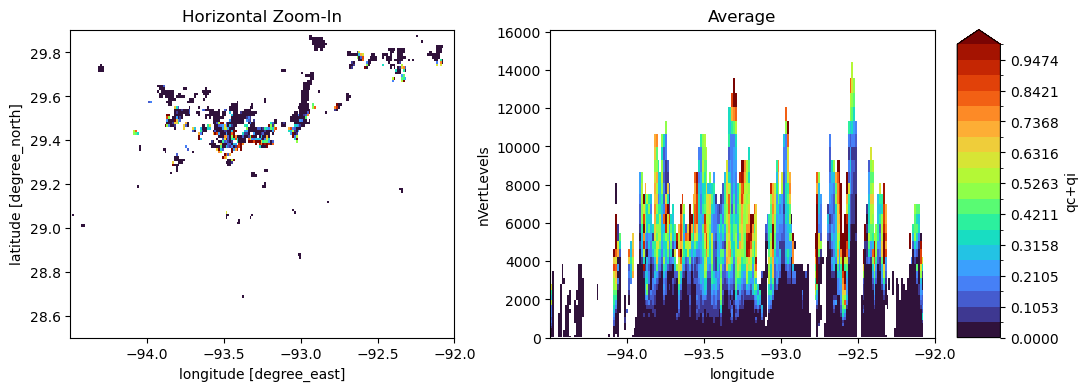

In [429]:
PlotHorizontalVertical(subsetData_NSSL*1000,varMean_NSSL*1000,varName="qc+qi",
                       cmap='turbo',levels=np.linspace(0,1,20))

In [435]:
# Other Variables
varName = 'relhum'
varData_NSSL = GetData(ModelData_NSSL, varName,t)
varData_TEMPO = GetData(ModelData_TEMPO, varName,t)

#reflectivity threshold
reflData_NSSL = GetData(ModelData_NSSL, "refl10cm",t)#.interp(nVertLevels=varData_NSSL.nVertLevelsP1)
reflData_TEMPO = GetData(ModelData_TEMPO, "refl10cm",t)#.interp(nVertLevels=varData_NSSL.nVertLevelsP1)
varData_NSSL = varData_NSSL.where(reflData_NSSL>40)
varData_TEMPO = varData_TEMPO.where(reflData_TEMPO>40)

# varData_NSSL=varData_NSSL-varData_NSSL.mean() #for perturbations
# varData_TEMPO=varData_TEMPO-varData_TEMPO.mean() #for perturbations

zdim = GetVerticalDim(varData_NSSL)
subsetData_NSSL = varData_NSSL.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

subsetData_TEMPO = varData_TEMPO.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

#mean
varMean_NSSL = GetMean(subsetData_NSSL,mode="y")
varMean_TEMPO = GetMean(subsetData_TEMPO,mode="y")

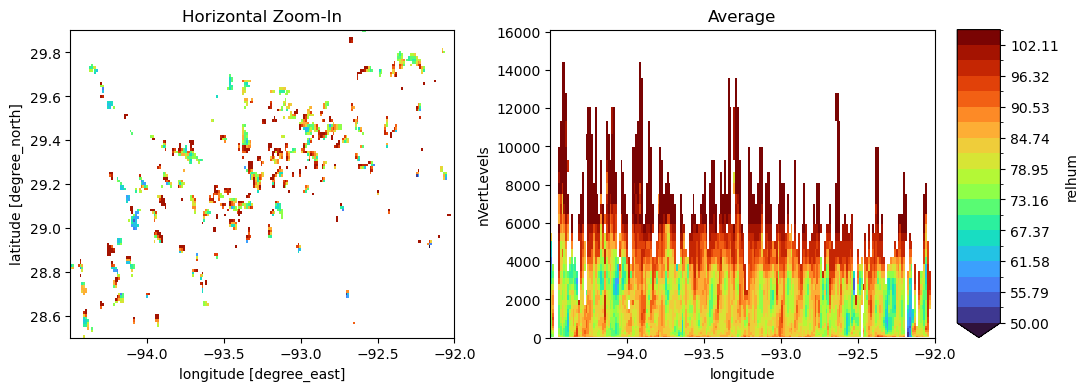

In [445]:
PlotHorizontalVertical(subsetData_TEMPO,varMean_TEMPO,varName="relhum",
                       cmap='turbo',levels=np.linspace(50,105,20))

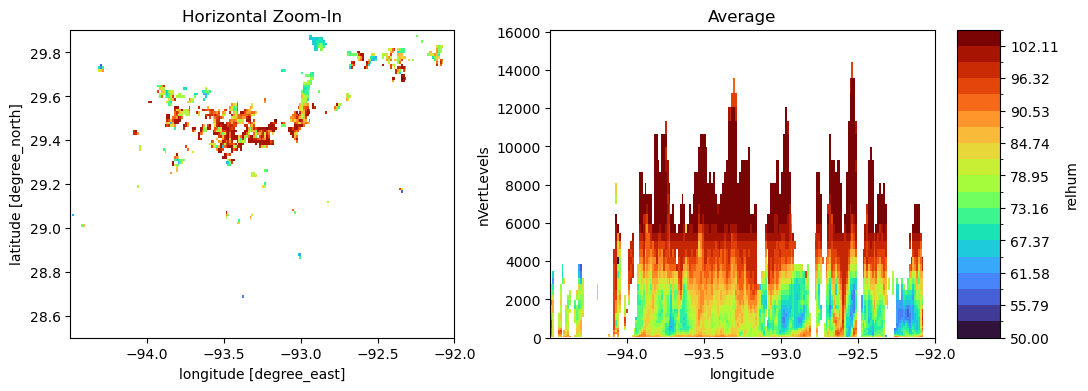

In [444]:
PlotHorizontalVertical(subsetData_NSSL,varMean_NSSL,varName="relhum",
                       cmap='turbo',levels=np.linspace(50,105,20))

In [446]:
# Other Variables
varName = 'qr'
varData_NSSL = GetData(ModelData_NSSL, varName,t)
varData_TEMPO = GetData(ModelData_TEMPO, varName,t)

#reflectivity threshold
reflData_NSSL = GetData(ModelData_NSSL, "refl10cm",t)#.interp(nVertLevels=varData_NSSL.nVertLevelsP1)
reflData_TEMPO = GetData(ModelData_TEMPO, "refl10cm",t)#.interp(nVertLevels=varData_NSSL.nVertLevelsP1)
varData_NSSL = varData_NSSL.where(reflData_NSSL>40)
varData_TEMPO = varData_TEMPO.where(reflData_TEMPO>40)

# varData_NSSL=varData_NSSL-varData_NSSL.mean() #for perturbations
# varData_TEMPO=varData_TEMPO-varData_TEMPO.mean() #for perturbations

zdim = GetVerticalDim(varData_NSSL)
subsetData_NSSL = varData_NSSL.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

subsetData_TEMPO = varData_TEMPO.sel({
    zdim: slice(0,16000),
    "longitude": slice(lon_min, lon_max),
    "latitude": slice(lat_min, lat_max)
})

#mean
varMean_NSSL = GetMean(subsetData_NSSL,mode="y")
varMean_TEMPO = GetMean(subsetData_TEMPO,mode="y")

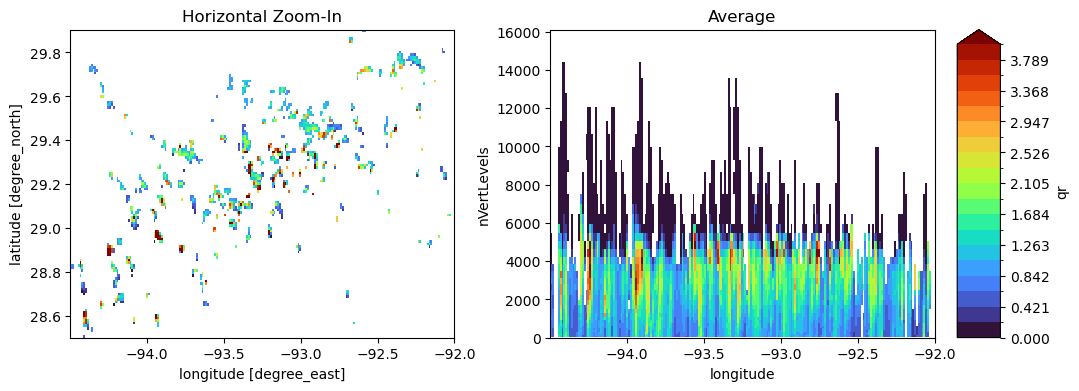

In [455]:
PlotHorizontalVertical(subsetData_TEMPO*1000,varMean_TEMPO*1000,varName="qr",
                       cmap='turbo',levels=np.linspace(0,4,20))

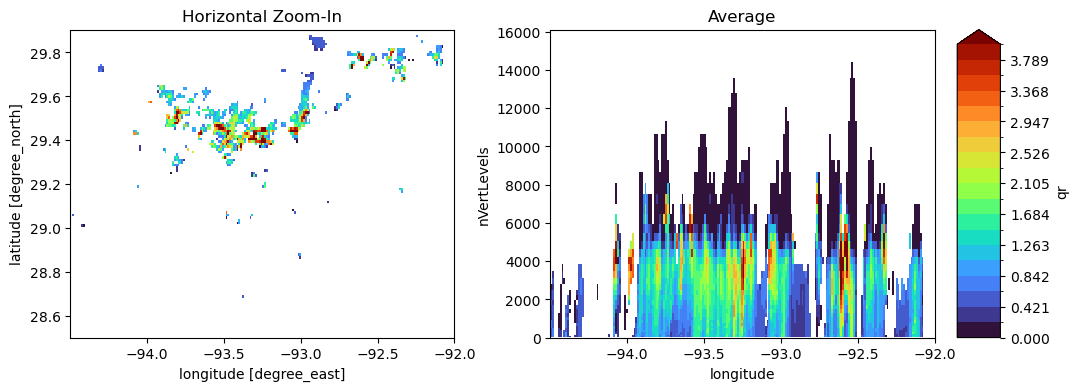

In [456]:
PlotHorizontalVertical(subsetData_NSSL*1000,varMean_NSSL*1000,varName="qr",
                       cmap='turbo',levels=np.linspace(0,4,20))

In [285]:
############################################################################
""" ROTATED RECTANGLE """

' ROTATED RECTANGLE '

In [259]:
####################################
#CALCULATION FUNCTIONS

In [260]:
def InterpToXYPlane(data,
                    lon0, lat0,
                    lon1, lat1,
                    width,
                    dx=0.01,
                    dy=0.01):

    # direction vector
    dx_line = lon1 - lon0
    dy_line = lat1 - lat0
    L = np.sqrt(dx_line**2 + dy_line**2)

    ux = dx_line / L
    uy = dy_line / L

    # perpendicular vector
    px = uy
    py = -ux

    # midpoint of center line
    lonc = (lon0 + lon1) / 2
    latc = (lat0 + lat1) / 2

    # determine number of grid points
    nx = max(2, int(np.ceil(L / dx)))
    ny = max(2, int(np.ceil(width / dy)))

    # coordinates in rotated frame
    x = np.linspace(-L/2, L/2, nx)
    y = np.linspace(-width/2, width/2, ny)

    X, Y = np.meshgrid(x, y)

    # transform to lon/lat
    lon_plane = lonc + ux*X + px*Y
    lat_plane = latc + uy*X + py*Y

    # interpolate
    interpData = data.interp(
        longitude=(("y","x"), lon_plane),
        latitude=(("y","x"), lat_plane)
    )

    interpData = interpData.assign_coords(
        x=("x", x),
        y=("y", y)
    )
    interpData = interpData.isel(x=slice(None, None, -1))
    interpData = interpData.assign_coords(x=interpData.x[::-1])

    return interpData

In [261]:
####################################
#PLOTTING FUNCTIONS

In [267]:
def PlotRotatedRectangleSlice(subsetData, sliceXY,
                              varName,
                              lon0, lat0,
                              lon1, lat1,
                              width):

    fig = plt.figure(figsize=(12,4))

    # outer grid
    outer = gridspec.GridSpec(1, 2, width_ratios=[20,1], wspace=0.05)

    # inner grid for the two plots
    inner = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[0], wspace=0.25
    )

    ax0 = fig.add_subplot(inner[0])
    ax1 = fig.add_subplot(inner[1])
    cax = fig.add_subplot(outer[1])

    # --- horizontal map ---
    p1 = subsetData.sel(nVertLevels=3000, method='nearest').plot(
        ax=ax0,
        cmap='turbo',
        add_colorbar=False
    )

    # draw rectangle
    PlotRectangleFromCenterLine(
        ax0,
        lon0, lat0,
        lon1, lat1,
        width
    )

    # --- rotated slice ---
    p2 = sliceXY.sel(nVertLevels=3000, method='nearest').plot(
        ax=ax1,
        cmap='turbo',
        add_colorbar=False
    )

    ax0.set_title("Horizontal Zoom-In")
    ax1.set_title("Rotated Slice")

    # shared colorbar
    fig.colorbar(p1, cax=cax, label=varName)

    plt.show()

In [268]:
####################################
#PLOTTING

In [ ]:
lon0=-92.25; lat0=29.6
lon1=-94.25; lat1=28.8
width=0.75

sliceXY_TEMPO = InterpToXYPlane(
        subsetData_TEMPO,
        lon0, lat0,
        lon1, lat1,
        width
    )

PlotRotatedRectangleSlice(
    subsetData_TEMPO,
    sliceXY_TEMPO,
    "Reflectivity (dBZ)",
    lon0, lat0,
    lon1, lat1,
    width
)

In [ ]:
sliceXY_TEMPO.mean(dim='y').plot(cmap='turbo')

In [ ]:
lon0=-92.25; lat0=29.6
lon1=-94.25; lat1=28.8
width=0.75

sliceXY_NSSL = InterpToXYPlane(
        subsetData_NSSL,
        lon0, lat0,
        lon1, lat1,
        width
    )

PlotRotatedRectangleSlice(
    subsetData_NSSL,
    sliceXY_NSSL,
    "Reflectivity (dBZ)",
    lon0, lat0,
    lon1, lat1,
    width
)

In [ ]:
sliceXY_NSSL.mean(dim='y').plot(cmap='turbo')

In [ ]:
############################################################################
""" OTHER """

In [ ]:
def ConvertLonLatToCartesian(data):

    lon = data.longitude
    lat = data.latitude

    lon0 = float(lon.min())
    lat0 = float(lat.min())

    # convert degrees → km
    x = (lon - lon0) * 111 * np.cos(np.deg2rad(float(lat.mean())))
    y = (lat - lat0) * 111

    # assign coordinates
    data_xy = data.assign_coords(
        x=("longitude", x.data),
        y=("latitude", y.data)
    )

    # replace dimensions
    data_xy = data_xy.swap_dims({
        "longitude": "x",
        "latitude": "y"
    })

    return data_xy